# v4 No-Regime 模型推理与结果解读

**目标**：自动加载 `data/` 下的数据集和 `submission_v4_NoRegime/model.pkl`，重建 v4 no-regime 的特征流程，完成验证集推理、测试集推理和可视化解读。

本 Notebook 包含：
1. 数据与模型自动加载
2. 两折验证结果汇总（AUC-PR / AUC-ROC / F1 / Precision / Recall）
3. 混淆矩阵热力图
4. ROC 曲线
5. Top 5 重要特征柱状图
6. 两个测试集的预测概览
7. 3 个典型预测样例（真实标签 vs 预测概率/异常分数）


In [1]:
# 1. 环境准备与数据/模型加载
import os
import pickle
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")
np.random.seed(42)

plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid")

def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "data" / "train.csv").exists() and (candidate / "submission_v4_NoRegime" / "model.pkl").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root from current working directory.")

ROOT = find_repo_root()
TRAIN_PATH = ROOT / "data" / "train.csv"
TEST_SIMPLE_PATH = ROOT / "data" / "test_simple.csv"
TEST_COMPLEX_PATH = ROOT / "data" / "test_complex.csv"
MODEL_PATH = ROOT / "submission_v4_NoRegime" / "model.pkl"
OUTPUT_DIR = ROOT / "notebooks" / "v4Notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CV_SPLITS = [131680, 134035]
FINAL_TRAIN_END = 135046

train_df = pd.read_csv(TRAIN_PATH)
test_simple_df = pd.read_csv(TEST_SIMPLE_PATH)
test_complex_df = pd.read_csv(TEST_COMPLEX_PATH)
feature_cols = [c for c in train_df.columns if c.startswith("f")]

medians = train_df[feature_cols].median()
for col in feature_cols:
    train_df[col] = train_df[col].fillna(medians[col])
    test_simple_df[col] = test_simple_df[col].fillna(medians[col])
    test_complex_df[col] = test_complex_df[col].fillna(medians[col])

with open(MODEL_PATH, "rb") as f:
    model_bundle = pickle.load(f)

print(f"Repo root: {ROOT}")
print(f"Train shape: {train_df.shape}")
print(f"Test simple shape: {test_simple_df.shape}")
print(f"Test complex shape: {test_complex_df.shape}")
print(f"Saved threshold: {model_bundle['threshold']:.6f}")
print(f"Saved feature count: {len(model_bundle['feature_cols'])}")
print(f"Selected feature count: {len(model_bundle['selected_features'])}")
print(f"CV folds stored in model: {len(model_bundle['cv_results'])}")
print("Final model keys:", sorted(model_bundle["models"].keys()))


Repo root: G:\MLProject\MLProject
Train shape: (137192, 34)
Test simple shape: (25647, 33)
Test complex shape: (34542, 33)
Saved threshold: 0.204013
Saved feature count: 316
Selected feature count: 100
CV folds stored in model: 2
Final model keys: ['cascade', 'iforest', 'lgb', 'lgb_sel', 'xgb_focal', 'xgb_std', 'xgb_std_sel']


## 数据与模型概览

这里会自动从仓库根目录加载训练集、两个测试集，以及已经训练好的 `submission_v4_NoRegime/model.pkl`。  
这样可以保证后续所有图表都基于同一份已保存模型，而不是临时重训出来的结果。


In [2]:
# 2. 特征重建与推理辅助函数
def create_features(df, feature_cols, lof_model=None, scaler_lof=None, pca_model=None, pca_scaler=None):
    features = pd.DataFrame(index=df.index)
    for col in feature_cols:
        features[col] = df[col].values

    for w in [5, 10, 20]:
        for col in feature_cols:
            features[f"{col}_rm{w}"] = df[col].rolling(window=w, min_periods=1).mean().values
            features[f"{col}_rs{w}"] = df[col].rolling(window=w, min_periods=1).std().fillna(0).values

    for col in feature_cols:
        features[f"{col}_d1"] = df[col].diff(1).fillna(0).values
        features[f"{col}_d5"] = df[col].diff(5).fillna(0).values

    for lag in [1, 3]:
        for col in feature_cols[:3]:
            features[f"{col}_l{lag}"] = df[col].shift(lag).bfill().ffill().values

    for i in range(min(3, len(feature_cols))):
        for j in range(i + 1, min(3, len(feature_cols))):
            features[f"i_{i}_{j}"] = (df[feature_cols[i]] * df[feature_cols[j]]).values

    X_raw = df[feature_cols].values
    if lof_model is not None:
        X_scaled = scaler_lof.transform(X_raw)
        lof_scores = lof_model.decision_function(X_scaled)
        features["lof_score"] = -lof_scores
    else:
        features["lof_score"] = 0

    row_data = df[feature_cols].values
    features["row_mean"] = row_data.mean(axis=1)
    features["row_std"] = row_data.std(axis=1)
    features["row_max"] = row_data.max(axis=1)
    features["row_min"] = row_data.min(axis=1)

    if pca_model is not None:
        X_scaled = pca_scaler.transform(X_raw)
        comps = pca_model.transform(X_scaled)
        for i in range(comps.shape[1]):
            features[f"pca_{i}"] = comps[:, i]

    return features

def preprocess(df, scaler=None, fit_scaler=False):
    df = df.copy().ffill().bfill()
    for col in df.columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    used_cols = [c for c in df.columns if c != "y"]
    if fit_scaler:
        scaler = StandardScaler()
        df[used_cols] = scaler.fit_transform(df[used_cols])
        return df, scaler
    df[used_cols] = scaler.transform(df[used_cols])
    return df

def fit_lof_pca(source_df, feature_cols):
    X_source = source_df[feature_cols].values

    scaler_lof = StandardScaler()
    X_lof = scaler_lof.fit_transform(X_source)
    sample_size = min(15000, len(X_lof))
    idx = np.random.choice(len(X_lof), sample_size, replace=False)
    lof_model = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination="auto", n_jobs=-1)
    lof_model.fit(X_lof[idx])

    pca_scaler = StandardScaler()
    X_pca = pca_scaler.fit_transform(X_source)
    pca_model = PCA(n_components=5, random_state=42)
    pca_model.fit(X_pca)

    return lof_model, scaler_lof, pca_model, pca_scaler

def temporal_smooth(scores, window=5):
    kernel = np.ones(window) / window
    return np.convolve(scores, kernel, mode="same")

def apply_temporal_consistency(predictions):
    result = predictions.copy()
    for i in range(len(predictions)):
        if predictions[i] == 1:
            left = result[max(0, i - 1)] if i > 0 else 0
            right = result[min(len(predictions) - 1, i + 1)] if i < len(predictions) - 1 else 0
            if left == 0 and right == 0:
                result[i] = 0
    return result

def align_columns(df, columns):
    aligned = df.copy()
    for col in columns:
        if col not in aligned.columns:
            aligned[col] = 0
    return aligned[columns]

def predict_ensemble(models, X, X_sel=None):
    pred_xgb_std = models["xgb_std"].predict(xgb.DMatrix(X))
    pred_xgb_focal = models["xgb_focal"].predict(xgb.DMatrix(X))
    pred_lgb = models["lgb"].predict(X, num_iteration=models["lgb"].best_iteration)
    if_scores = models["iforest"].decision_function(X)
    pred_if = 1 - (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min() + 1e-8)

    base = 0.25 * pred_xgb_std + 0.25 * pred_xgb_focal + 0.25 * pred_lgb + 0.25 * pred_if

    cascade = models.get("cascade")
    if cascade is not None:
        cascade_if_scores = cascade["if_model"].decision_function(X)
        cascade_if_probs = 1 - (cascade_if_scores - cascade_if_scores.min()) / (
            cascade_if_scores.max() - cascade_if_scores.min() + 1e-8
        )
        refine_probs = cascade["refine_model"].predict(xgb.DMatrix(X))
        base = 0.7 * base + 0.3 * (cascade_if_probs * refine_probs)

    if X_sel is not None and "xgb_std_sel" in models and "lgb_sel" in models:
        pred_xgb_sel = models["xgb_std_sel"].predict(xgb.DMatrix(X_sel))
        pred_lgb_sel = models["lgb_sel"].predict(X_sel, num_iteration=models["lgb_sel"].best_iteration)
        base = 0.8 * base + 0.2 * (0.5 * pred_xgb_sel + 0.5 * pred_lgb_sel)

    return temporal_smooth(base, window=5)

def rebuild_fold_validation(train_df, feature_cols, fold_model, train_end, threshold):
    train_raw = train_df.iloc[:train_end].copy()
    val_raw = train_df.iloc[train_end:].copy()
    y_val = val_raw["y"].values

    lof_model, scaler_lof, pca_model, pca_scaler = fit_lof_pca(train_raw, feature_cols)
    val_fe = create_features(val_raw.drop(columns=["y"]), feature_cols, lof_model, scaler_lof, pca_model, pca_scaler)
    val_fe = align_columns(val_fe, fold_model["feature_cols"])
    val_scaled = preprocess(val_fe, scaler=fold_model["scaler"])
    X_val = val_scaled.values

    scores = predict_ensemble(fold_model, X_val)
    pred = apply_temporal_consistency((scores >= threshold).astype(int))

    auc_pr = average_precision_score(y_val, scores)
    auc_roc = roc_auc_score(y_val, scores)
    f1 = f1_score(y_val, pred)
    precision = precision_score(y_val, pred, zero_division=0)
    recall = recall_score(y_val, pred, zero_division=0)

    return {
        "train_end": train_end,
        "val_raw": val_raw,
        "y_val": y_val,
        "scores": scores,
        "pred": pred,
        "threshold": threshold,
        "auc_pr": auc_pr,
        "auc_roc": auc_roc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "predicted_anomalies": int(pred.sum()),
    }


## 推理流程说明

`model.pkl` 里保存了最终模型和每折验证模型，但没有直接保存 LOF/PCA 辅助变换器。  
因此这里会按原始 no-regime v4 逻辑，基于对应训练切分重新拟合 LOF/PCA，再把特征送入已保存模型做推理。


In [3]:
# 3. 两折验证结果汇总
fold_eval_results = []
for split, fold_result in zip(CV_SPLITS, model_bundle["cv_results"]):
    fold_eval = rebuild_fold_validation(
        train_df=train_df,
        feature_cols=feature_cols,
        fold_model=fold_result["models"],
        train_end=split,
        threshold=float(fold_result["threshold"]),
    )
    fold_eval_results.append(fold_eval)

metrics_rows = []
for idx, fold_eval in enumerate(fold_eval_results, start=1):
    metrics_rows.append({
        "版本": f"Fold {idx}",
        "切分点": fold_eval["train_end"],
        "验证集行数": len(fold_eval["y_val"]),
        "验证集异常数": int(fold_eval["y_val"].sum()),
        "AUC-PR": round(fold_eval["auc_pr"], 4),
        "AUC-ROC": round(fold_eval["auc_roc"], 4),
        "F1-Score": round(fold_eval["f1"], 4),
        "Precision": round(fold_eval["precision"], 4),
        "Recall": round(fold_eval["recall"], 4),
        "阈值": round(float(fold_eval["threshold"]), 4),
        "预测异常数": fold_eval["predicted_anomalies"],
    })

metrics_df = pd.DataFrame(metrics_rows)
cv_avg_row = {
    "版本": "CV Average",
    "切分点": "-",
    "验证集行数": int(np.mean(metrics_df["验证集行数"])),
    "验证集异常数": int(np.mean(metrics_df["验证集异常数"])),
    "AUC-PR": round(metrics_df["AUC-PR"].mean(), 4),
    "AUC-ROC": round(metrics_df["AUC-ROC"].mean(), 4),
    "F1-Score": round(metrics_df["F1-Score"].mean(), 4),
    "Precision": round(metrics_df["Precision"].mean(), 4),
    "Recall": round(metrics_df["Recall"].mean(), 4),
    "阈值": round(metrics_df["阈值"].mean(), 4),
    "预测异常数": int(np.mean(metrics_df["预测异常数"])),
}
metrics_df = pd.concat([metrics_df, pd.DataFrame([cv_avg_row])], ignore_index=True)
display(metrics_df)

best_fold_idx = int(np.argmax([item["f1"] for item in fold_eval_results]))
best_fold_eval = fold_eval_results[best_fold_idx]
print(f"最佳验证版本：Fold {best_fold_idx + 1}")
print(f"AUC-PR={best_fold_eval['auc_pr']:.4f}, AUC-ROC={best_fold_eval['auc_roc']:.4f}, F1={best_fold_eval['f1']:.4f}")


           版本     切分点  验证集行数  验证集异常数  ...  Precision  Recall      阈值  预测异常数
0      Fold 1  131680   5512     210  ...     0.9500  0.9048  0.1721    200
1      Fold 2  134035   3157     120  ...     0.9573  0.9333  0.2040    117
2  CV Average       -   4334     165  ...     0.9536  0.9190  0.1880    158

[3 rows x 11 columns]
最佳验证版本：Fold 2
AUC-PR=0.9869, AUC-ROC=0.9993, F1=0.9451


## 验证结果解读

这张表总结了 v4 no-regime 在两次时间切分上的验证表现。  
如果两折分数接近，说明模型不只是在某一个切分点上表现好，而是在不同时间段都有较稳定的识别能力。


TN=3032, FP=5, FN=8, TP=112
Precision=0.9573, Recall=0.9333, F1=0.9451


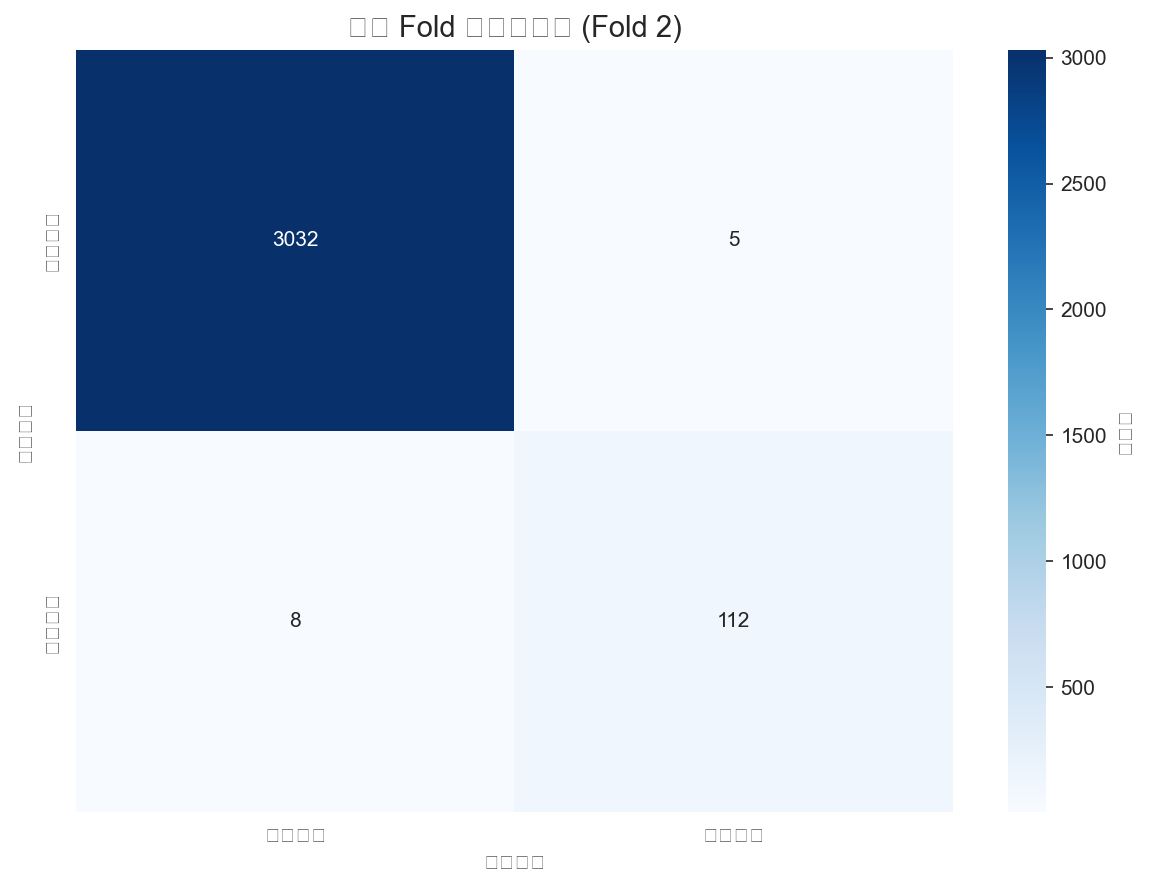

In [4]:
# 4. 混淆矩阵热力图（最佳 fold）
cm = confusion_matrix(best_fold_eval["y_val"], best_fold_eval["pred"])
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["预测正常", "预测异常"],
    yticklabels=["真实正常", "真实异常"],
    cbar_kws={"label": "样本数"},
)
plt.title(f"最佳 Fold 的混淆矩阵 (Fold {best_fold_idx + 1})", fontsize=14)
plt.xlabel("预测标签")
plt.ylabel("真实标签")
plt.tight_layout()
plt.show()

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Precision={best_fold_eval['precision']:.4f}, Recall={best_fold_eval['recall']:.4f}, F1={best_fold_eval['f1']:.4f}")


## 混淆矩阵解读

混淆矩阵可以直接看出模型把多少正常样本和异常样本分对了。  
右下角数字越大越好，说明模型抓到了更多真实异常；右上角越小越好，说明误报更少。


AUC-ROC=0.9993
较优平衡点：TPR=98.33%, FPR=0.89%


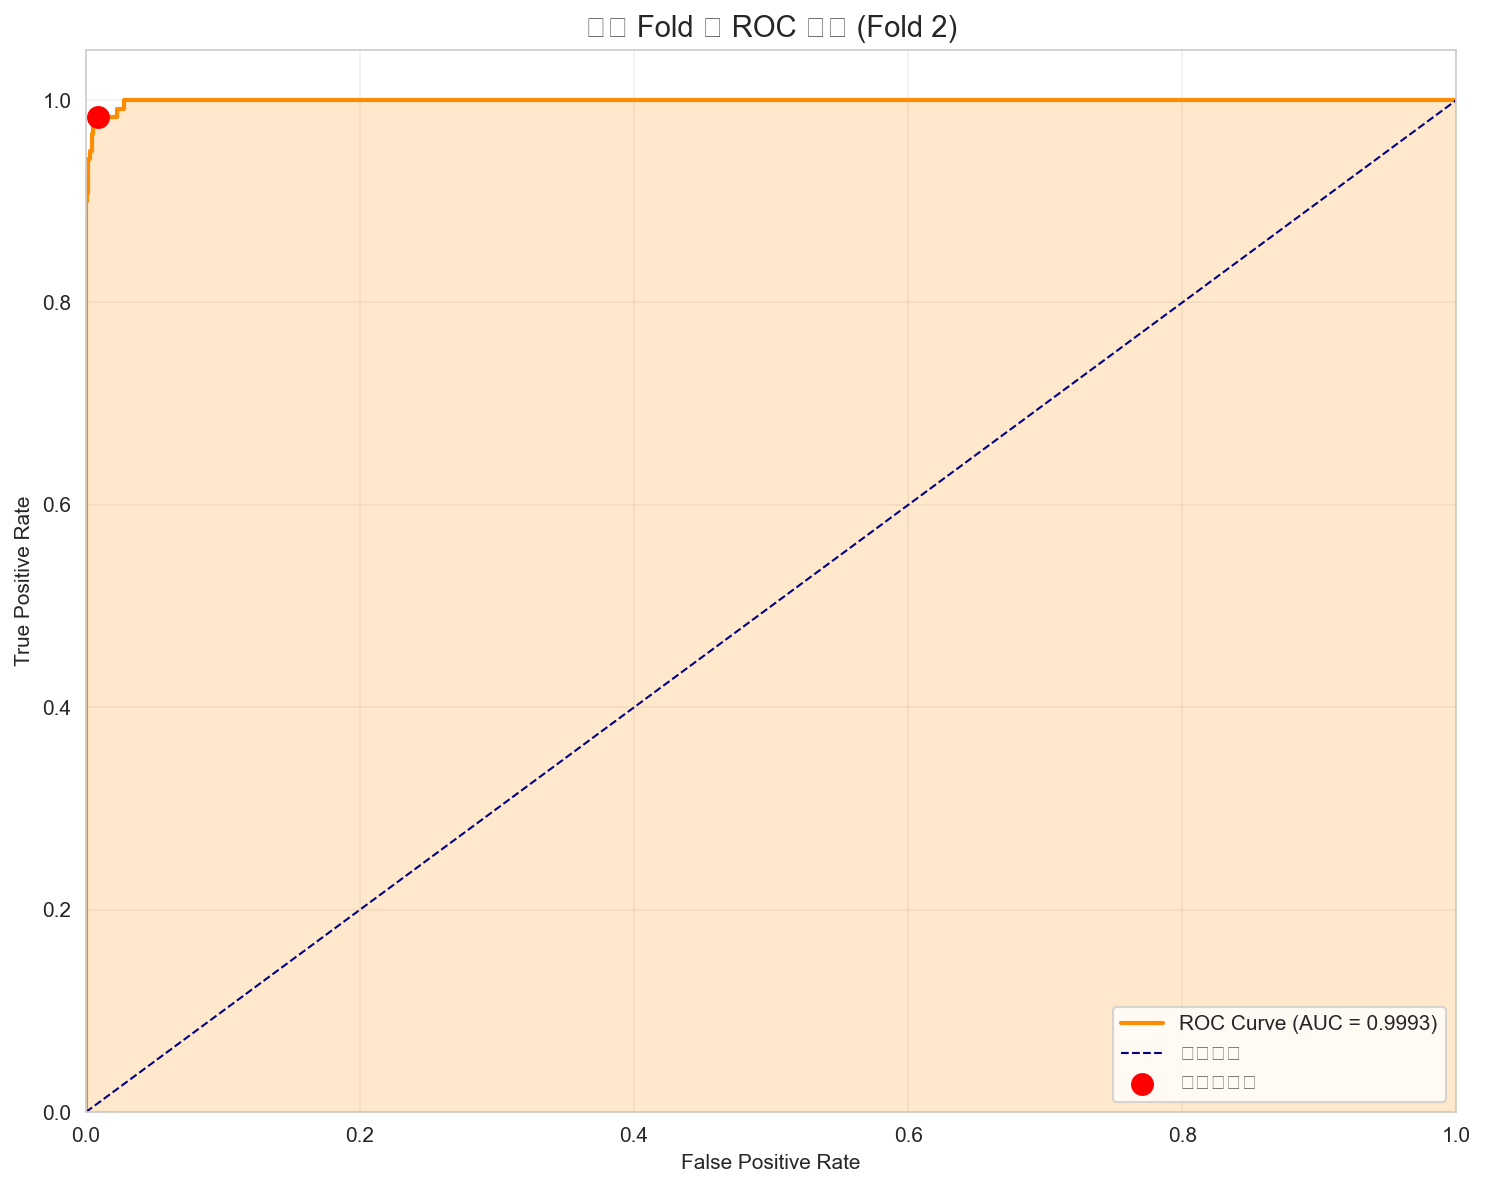

In [5]:
# 5. ROC 曲线（最佳 fold）
fpr, tpr, roc_thresholds = roc_curve(best_fold_eval["y_val"], best_fold_eval["scores"])

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {best_fold_eval['auc_roc']:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="随机基线")

optimal_idx = int(np.argmax(tpr - fpr))
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]
plt.scatter([optimal_fpr], [optimal_tpr], color="red", s=100, zorder=5, label="较优平衡点")

plt.fill_between(fpr, tpr, alpha=0.2, color="darkorange")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"最佳 Fold 的 ROC 曲线 (Fold {best_fold_idx + 1})", fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC-ROC={best_fold_eval['auc_roc']:.4f}")
print(f"较优平衡点：TPR={optimal_tpr:.2%}, FPR={optimal_fpr:.2%}")


## ROC 曲线解读

ROC 曲线看的是“模型排序能力”，即异常样本是否总体上被排在更高分的位置。  
曲线越靠左上角，说明模型越能把异常与正常区分开；AUC 越接近 1，整体排序能力越强。


    feature    importance
0   f32_rs5  6.199058e+06
1   f33_rs5  2.192010e+06
2  f27_rs10  1.623900e+06
3  f23_rm20  1.097992e+06
4   f24_rm5  9.710455e+05


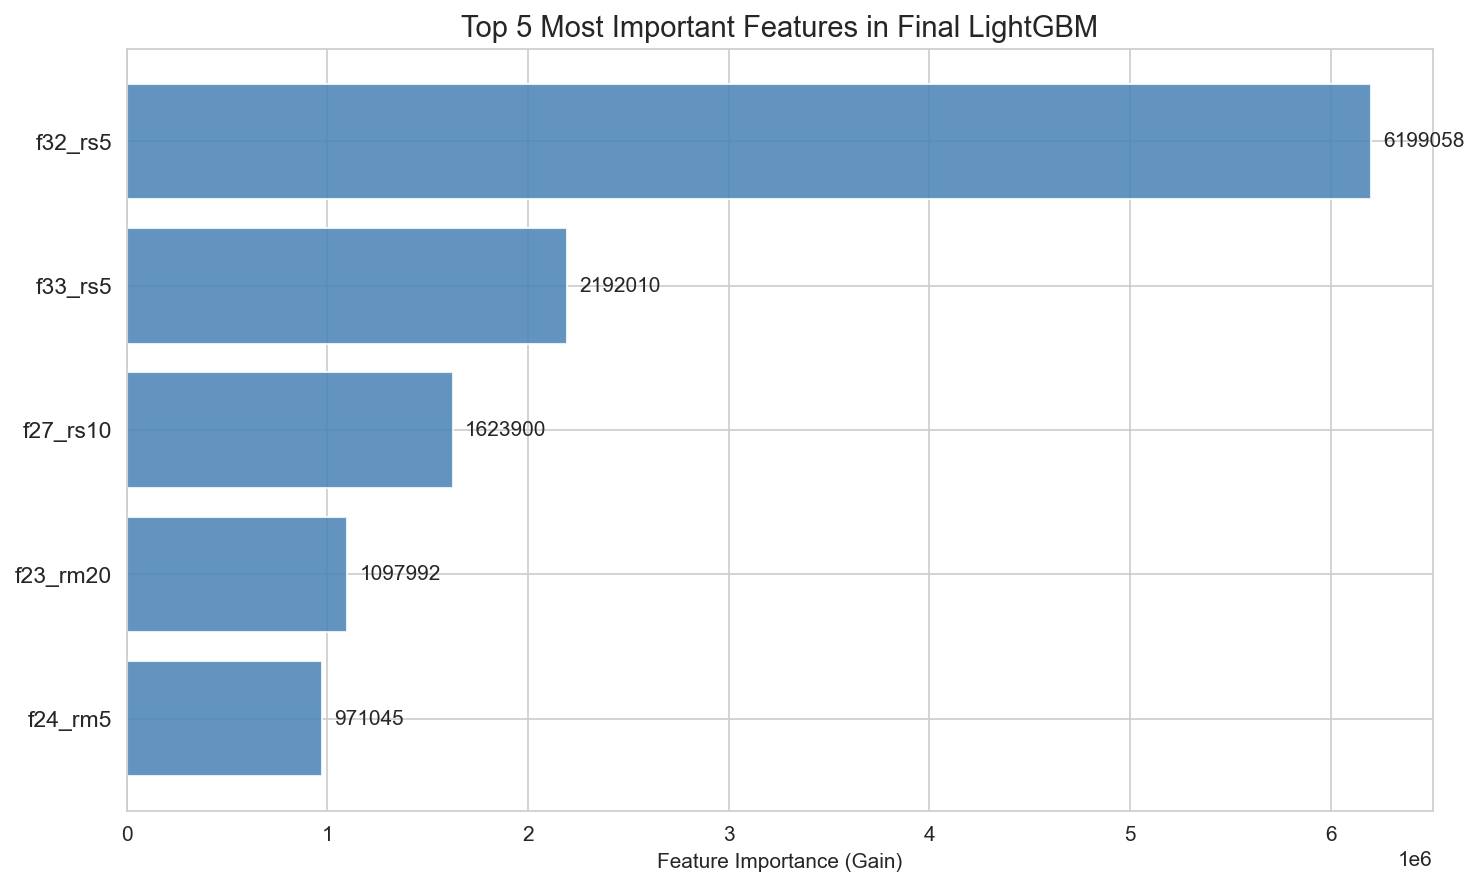

In [6]:
# 6. Top 5 重要特征柱状图（最终模型）
final_feature_names = model_bundle["feature_cols"]
importance = model_bundle["models"]["lgb"].feature_importance(importance_type="gain")
importance_df = pd.DataFrame({
    "feature": final_feature_names,
    "importance": importance,
}).sort_values("importance", ascending=False)

top5 = importance_df.head(5)

plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(top5)), top5["importance"].values, color="steelblue", alpha=0.85)
plt.yticks(range(len(top5)), top5["feature"].values, fontsize=11)
plt.xlabel("Feature Importance (Gain)")
plt.title("Top 5 Most Important Features in Final LightGBM", fontsize=14)
plt.gca().invert_yaxis()

for idx, (bar, value) in enumerate(zip(bars, top5["importance"].values)):
    plt.text(value + top5["importance"].max() * 0.01, idx, f"{value:.0f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

display(top5.reset_index(drop=True))


## 重要特征解读

这里展示的是最终 LightGBM 最依赖的 5 个特征。  
如果某些滚动统计、LOF 分数或 PCA 特征排在前面，说明模型不是只看单点数值，而是在综合局部趋势和整体异常形态做判断。


            数据集   总样本数  预测异常数    异常率   分数最小值    分数均值   分数最大值
0   test_simple  25647    859  3.35%  0.0024  0.0401  0.6821
1  test_complex  34542    636  1.84%  0.0021  0.0284  0.6521


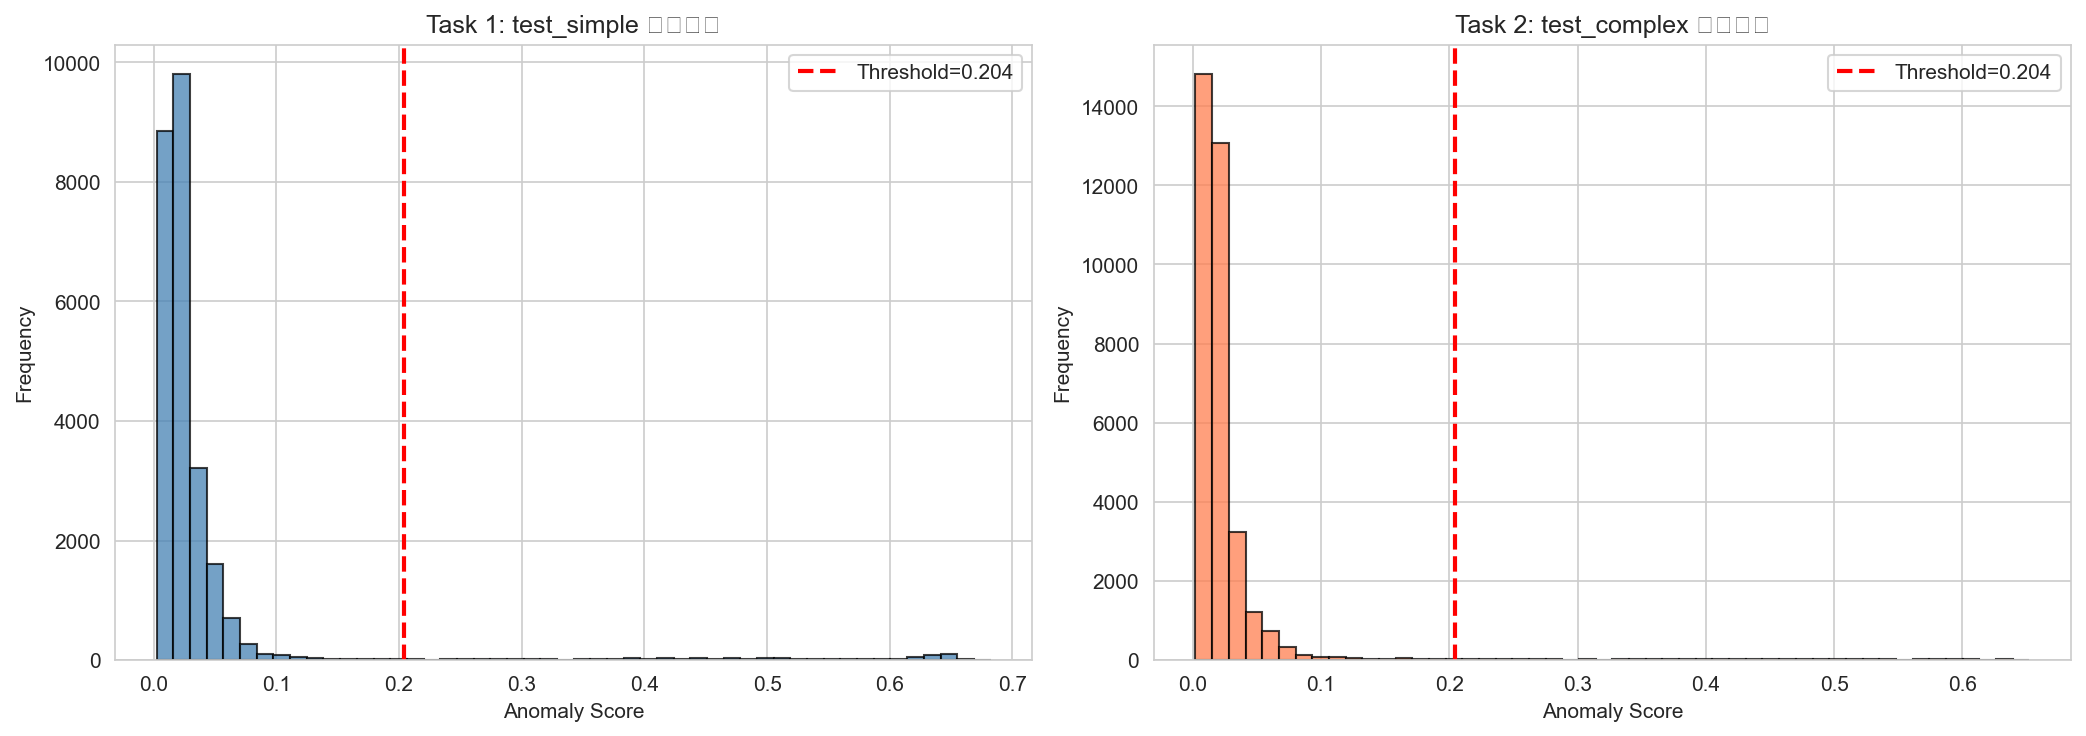

In [7]:
# 7. 两个测试集的预测结果概览
final_train = train_df.iloc[:FINAL_TRAIN_END].copy()
final_y = final_train["y"].values
lof_model, scaler_lof, pca_model, pca_scaler = fit_lof_pca(final_train, feature_cols)

final_train_fe = create_features(final_train.drop(columns=["y"]), feature_cols, lof_model, scaler_lof, pca_model, pca_scaler)
final_feature_cols = model_bundle["feature_cols"]
final_train_fe = align_columns(final_train_fe, final_feature_cols)
final_train_scaled = preprocess(final_train_fe, scaler=model_bundle["scaler"])
X_final_train = final_train_scaled.values

test_simple_fe = create_features(test_simple_df, feature_cols, lof_model, scaler_lof, pca_model, pca_scaler)
test_complex_fe = create_features(test_complex_df, feature_cols, lof_model, scaler_lof, pca_model, pca_scaler)
test_simple_fe = align_columns(test_simple_fe, final_feature_cols)
test_complex_fe = align_columns(test_complex_fe, final_feature_cols)

test_simple_scaled = preprocess(test_simple_fe, scaler=model_bundle["scaler"])
test_complex_scaled = preprocess(test_complex_fe, scaler=model_bundle["scaler"])
X_test_simple = test_simple_scaled.values
X_test_complex = test_complex_scaled.values

selected_idx = [final_feature_cols.index(name) for name in model_bundle["selected_features"]]
X_test_simple_sel = X_test_simple[:, selected_idx]
X_test_complex_sel = X_test_complex[:, selected_idx]

scores_simple = predict_ensemble(model_bundle["models"], X_test_simple, X_test_simple_sel)
scores_complex = predict_ensemble(model_bundle["models"], X_test_complex, X_test_complex_sel)
pred_simple = apply_temporal_consistency((scores_simple >= model_bundle["threshold"]).astype(int))
pred_complex = apply_temporal_consistency((scores_complex >= model_bundle["threshold"]).astype(int))

summary_df = pd.DataFrame([
    {
        "数据集": "test_simple",
        "总样本数": len(pred_simple),
        "预测异常数": int(pred_simple.sum()),
        "异常率": f"{pred_simple.mean() * 100:.2f}%",
        "分数最小值": round(float(scores_simple.min()), 4),
        "分数均值": round(float(scores_simple.mean()), 4),
        "分数最大值": round(float(scores_simple.max()), 4),
    },
    {
        "数据集": "test_complex",
        "总样本数": len(pred_complex),
        "预测异常数": int(pred_complex.sum()),
        "异常率": f"{pred_complex.mean() * 100:.2f}%",
        "分数最小值": round(float(scores_complex.min()), 4),
        "分数均值": round(float(scores_complex.mean()), 4),
        "分数最大值": round(float(scores_complex.max()), 4),
    },
])
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(scores_simple, bins=50, color="steelblue", alpha=0.75, edgecolor="black")
axes[0].axvline(model_bundle["threshold"], color="red", linestyle="--", linewidth=2, label=f"Threshold={model_bundle['threshold']:.3f}")
axes[0].set_title("Task 1: test_simple 分数分布")
axes[0].set_xlabel("Anomaly Score")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(scores_complex, bins=50, color="coral", alpha=0.75, edgecolor="black")
axes[1].axvline(model_bundle["threshold"], color="red", linestyle="--", linewidth=2, label=f"Threshold={model_bundle['threshold']:.3f}")
axes[1].set_title("Task 2: test_complex 分数分布")
axes[1].set_xlabel("Anomaly Score")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()


## 测试集概览解读

这部分展示模型在两个无标签测试集上的预测异常数量和分数分布。  
如果 `test_complex` 的异常率明显不同于 `test_simple`，通常说明模型感知到了更复杂或不同分布的数据模式。


           类型    全局索引  验证集局部索引  真实标签  ...     阈值      f1      f2      f3
0  A. 高置信度真阳性  134572      537     1  ...  0.204 -0.8942 -0.8952 -0.9104
1  B. 高置信度假阳性  134575      540     0  ...  0.204 -0.8942 -0.8952 -0.9104
2  C. 高置信度假阴性  135525     1490     1  ...  0.204  0.3093  0.3200  0.3166

[3 rows x 10 columns]


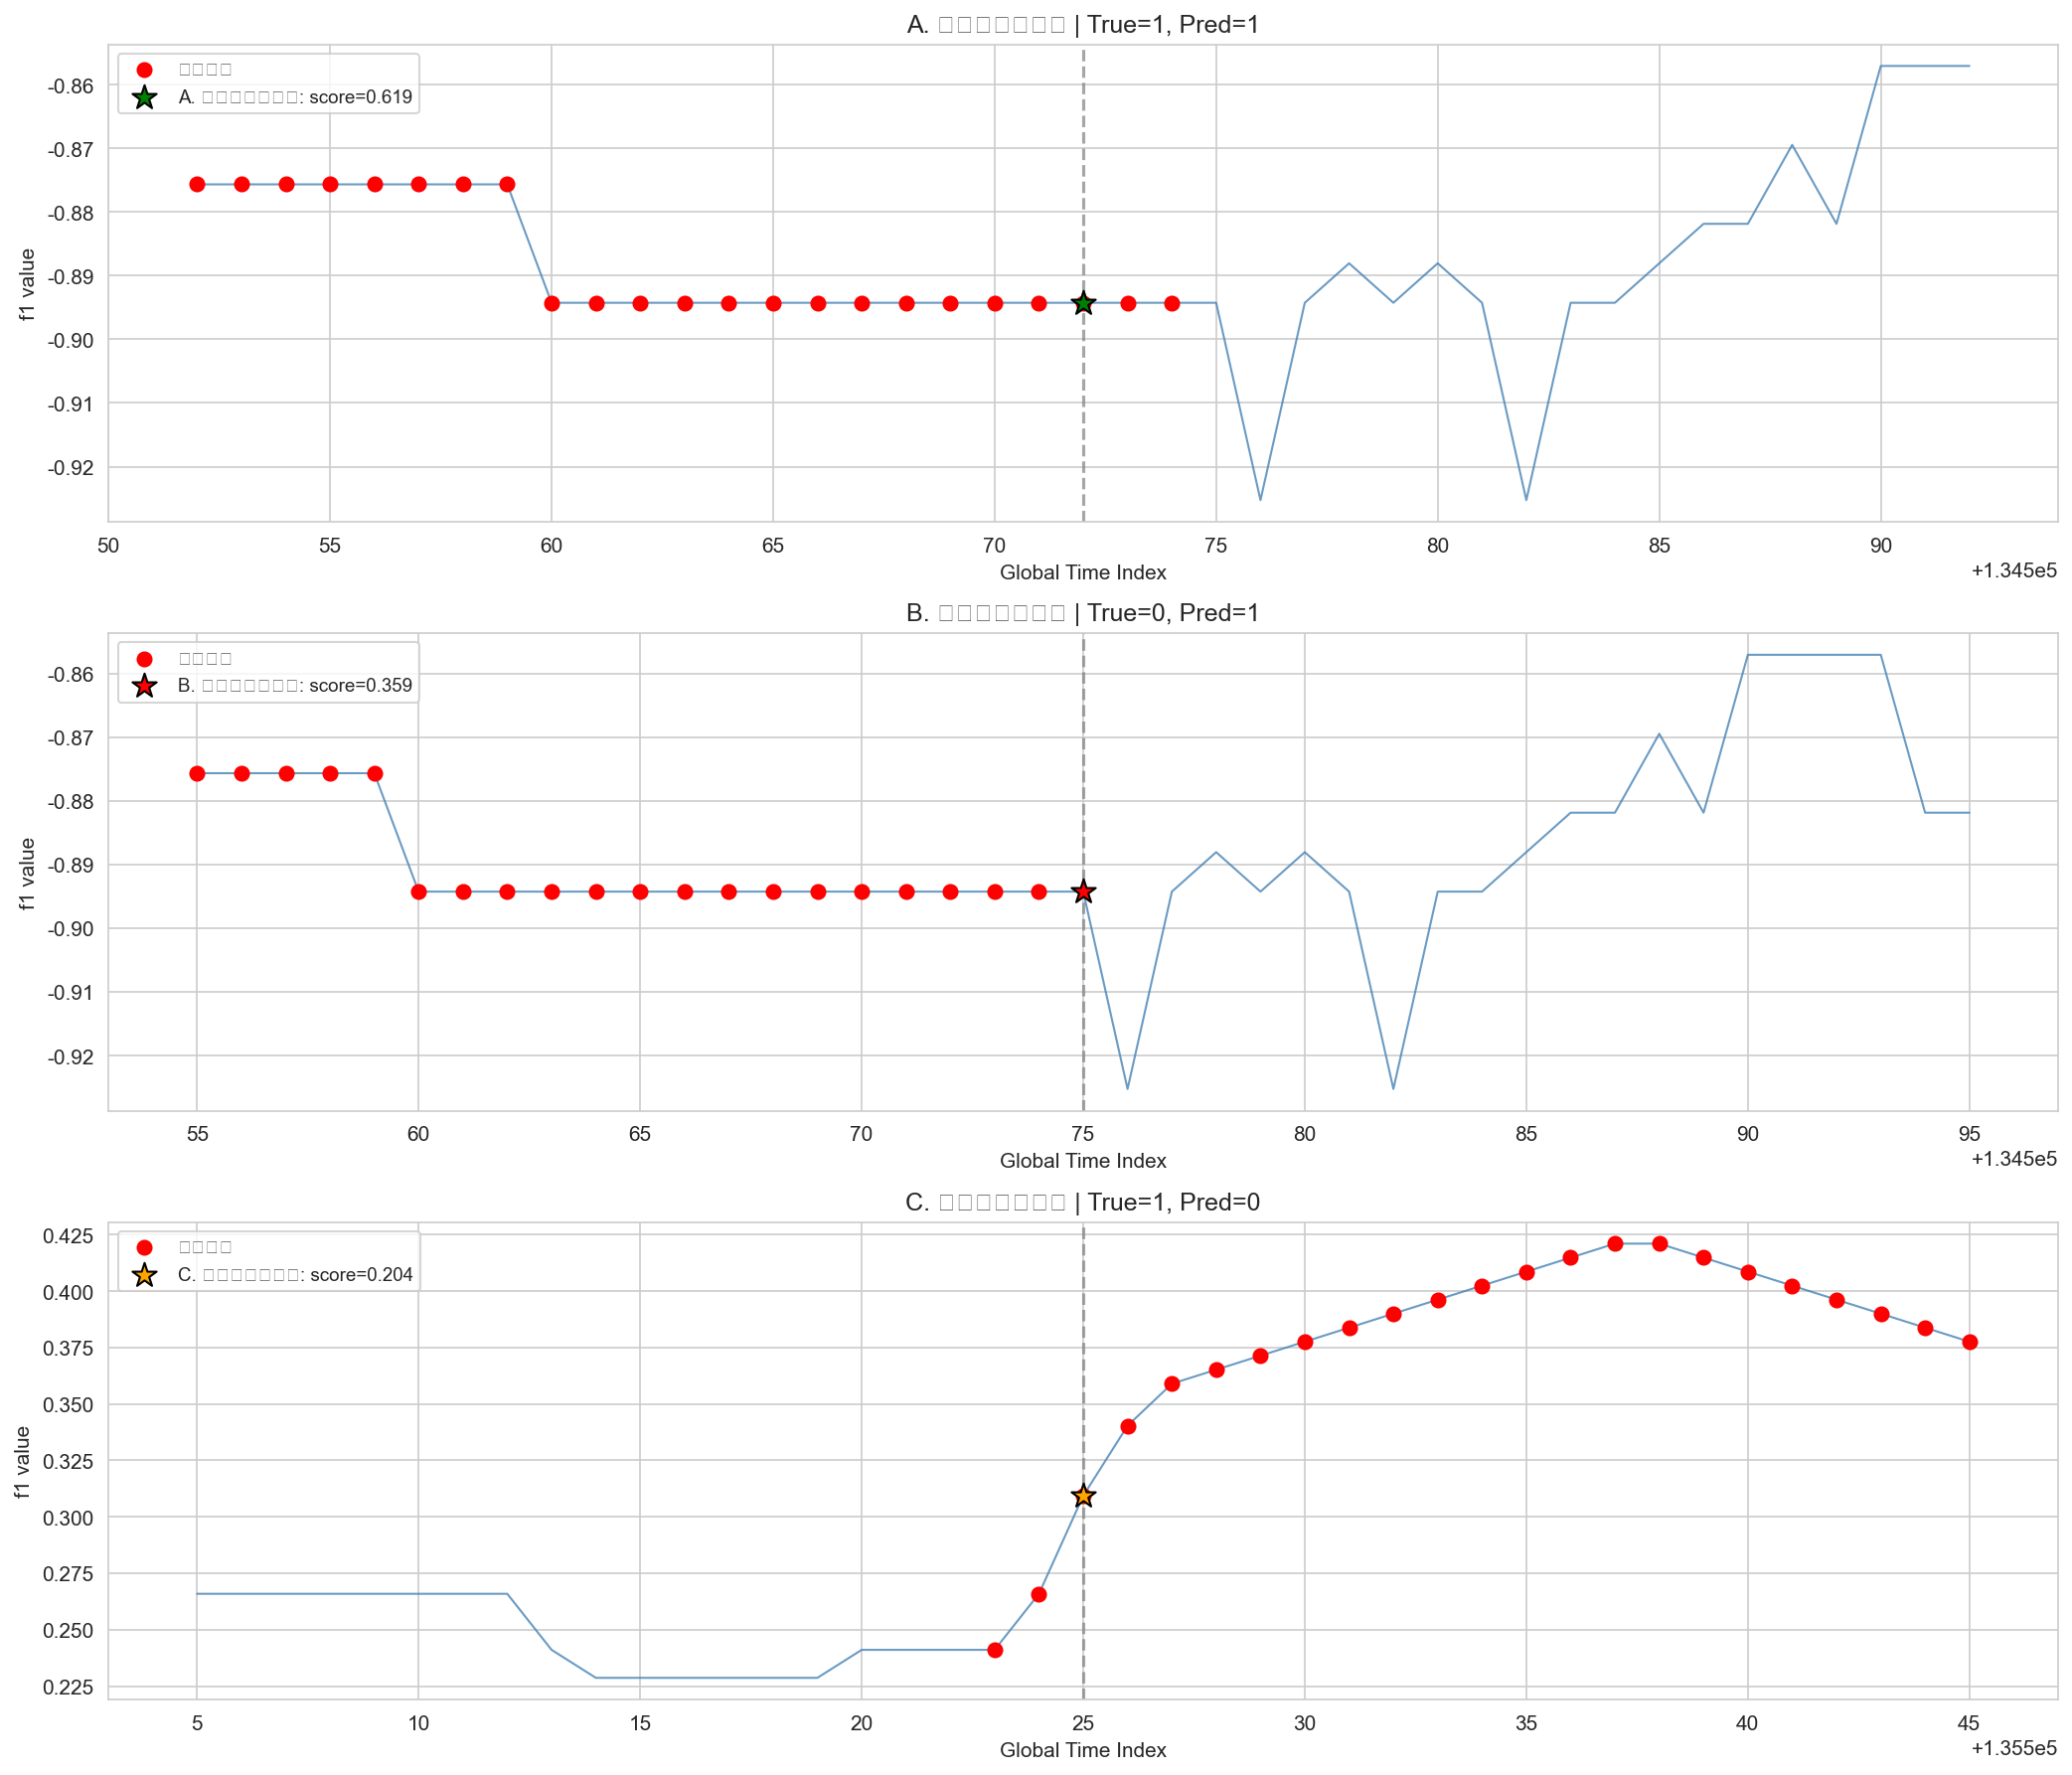

In [8]:
# 8. 3 个典型预测样例（最佳 fold 验证集）
tp_mask = (best_fold_eval["y_val"] == 1) & (best_fold_eval["pred"] == 1)
fp_mask = (best_fold_eval["y_val"] == 0) & (best_fold_eval["pred"] == 1)
fn_mask = (best_fold_eval["y_val"] == 1) & (best_fold_eval["pred"] == 0)

examples = []

if tp_mask.any():
    tp_idx = np.where(tp_mask)[0][np.argmax(best_fold_eval["scores"][tp_mask])]
    examples.append(("A. 高置信度真阳性", tp_idx, "green"))

if fp_mask.any():
    fp_idx = np.where(fp_mask)[0][np.argmax(best_fold_eval["scores"][fp_mask])]
    examples.append(("B. 高置信度假阳性", fp_idx, "red"))

if fn_mask.any():
    fn_idx = np.where(fn_mask)[0][np.argmax(best_fold_eval["scores"][fn_mask])]
    examples.append(("C. 高置信度假阴性", fn_idx, "orange"))

example_rows = []
for label, local_idx, color in examples:
    global_idx = best_fold_eval["train_end"] + local_idx
    sample = best_fold_eval["val_raw"].iloc[local_idx]
    example_rows.append({
        "类型": label,
        "全局索引": int(global_idx),
        "验证集局部索引": int(local_idx),
        "真实标签": int(best_fold_eval["y_val"][local_idx]),
        "预测标签": int(best_fold_eval["pred"][local_idx]),
        "预测概率/异常分数": round(float(best_fold_eval["scores"][local_idx]), 4),
        "阈值": round(float(best_fold_eval["threshold"]), 4),
        "f1": round(float(sample["f1"]), 4),
        "f2": round(float(sample["f2"]), 4),
        "f3": round(float(sample["f3"]), 4),
    })

example_df = pd.DataFrame(example_rows)
display(example_df)

fig, axes = plt.subplots(len(examples), 1, figsize=(14, 4 * max(1, len(examples))))
if len(examples) == 1:
    axes = [axes]

for ax, (label, local_idx, color) in zip(axes, examples):
    start = max(0, local_idx - 20)
    end = min(len(best_fold_eval["val_raw"]), local_idx + 21)
    local_indices = np.arange(start, end) + best_fold_eval["train_end"]
    local_f1 = best_fold_eval["val_raw"]["f1"].iloc[start:end].values
    local_y = best_fold_eval["y_val"][start:end]

    ax.plot(local_indices, local_f1, color="steelblue", linewidth=1, alpha=0.8)
    anomaly_points = local_indices[local_y == 1]
    anomaly_values = local_f1[local_y == 1]
    if len(anomaly_points) > 0:
        ax.scatter(anomaly_points, anomaly_values, color="red", s=45, zorder=5, label="真实异常")

    global_idx = best_fold_eval["train_end"] + local_idx
    current_value = best_fold_eval["val_raw"]["f1"].iloc[local_idx]
    current_score = best_fold_eval["scores"][local_idx]
    current_true = best_fold_eval["y_val"][local_idx]
    current_pred = best_fold_eval["pred"][local_idx]

    ax.scatter([global_idx], [current_value], color=color, s=150, marker="*", edgecolors="black", linewidth=1.0,
               zorder=6, label=f"{label}: score={current_score:.3f}")
    ax.axvline(global_idx, color="gray", linestyle="--", alpha=0.7)
    ax.set_title(f"{label} | True={current_true}, Pred={current_pred}")
    ax.set_xlabel("Global Time Index")
    ax.set_ylabel("f1 value")
    ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()


## 典型样例解读

这 3 个样例分别代表“模型判断正确的异常”“模型误报的正常样本”和“模型漏掉的异常样本”。  
把这些样例放回时间上下文里观察，能帮助非技术人员理解模型为什么会做出这样的判断，而不只是看一个分数。
